# Проект: Исследование стартапов
Автор: Цуриков А.В.

## Введение

### Цели и задачи проекта

Заказчик хочет выйти на инвестиционный рынок. Для разработки модели бизнеса требуется больше информации. Мы будем изучать исторические данные и поможем ему выработать общее понимание


## Знакомство с данными: загрузка и первичная предобработка

Для работы нам предоставили 7 таблиц:
* acquisition.csv
* company_and_rounds.csv
* degrees.csv
* education.csv
* fund.csv
* investment.csv
* people.csv  

Ниже мы изучим их подробнее и опишем

### Вывод общей информации, исправление названия столбцов

#### Импорт библиотек

In [1]:
# Установим phi_k
!pip install phik

In [2]:
# Импортируем библиотеки
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from phik import phik_matrix

#### Загрузка данных

In [3]:
# Создадим все необходимые датафреймы
acquisition = pd.read_csv('https://code.s3.yandex.net/datasets/acquisition.csv')
company_and_rounds = pd.read_csv('https://code.s3.yandex.net/datasets/company_and_rounds.csv')
degrees = pd.read_csv('https://code.s3.yandex.net/datasets/degrees.csv')
education = pd.read_csv('https://code.s3.yandex.net/datasets/education.csv')
fund = pd.read_csv('https://code.s3.yandex.net/datasets/fund.csv')
investment = pd.read_csv('https://code.s3.yandex.net/datasets/investment.csv')
people = pd.read_csv('https://code.s3.yandex.net/datasets/people.csv')

##### Изучаем таблицу acquisition
Содержит информацию о покупках одними компаниями других компаний:

In [4]:
# Изучим названия столбцов acquisition 
acquisition.columns

Index(['id', 'acquiring_company_id', 'acquired_company_id', 'term_code',
       'price_amount', 'acquired_at'],
      dtype='object')

Названия столбцов в стиле snake_case, менять не требуется. 

In [5]:
acquisition.head()

,id,acquiring_company_id,acquired_company_id,term_code,price_amount,acquired_at
0,1,11,10,NaN,20000000,2007-05-30
1,7,59,72,cash,60000000,2007-07-01
2,8,24,132,cash,280000000,2007-05-01
3,9,59,155,cash,100000000,2007-06-01
4,10,212,215,cash,25000000,2007-07-01


* id — идентификатор покупки.
* acquiring_company_id — идентификатор покупающей компании.
* acquired_company_id — идентификатор покупаемой компании.
* term_code — варианты расчёта.
* price_amount — сумма сделки.
* acquired_at — дата сделки.

##### Изучаем таблицу company_and_rounds
Содержит информацию о компаниях и раундах финансирования:

In [6]:
# Изучим company_and_rounds
company_and_rounds.columns

Index(['company  ID', 'name', 'category  code', 'status', 'founded  at',
       'closed  at', 'domain', 'network  username', 'country  code',
       'investment  rounds', 'funding  rounds', 'funding  total', 'milestones',
       'funding  round  id', 'company  id', 'funded  at',
       'funding  round  type', 'raised  amount', 'pre  money  valuation',
       'participants', 'is  first  round', 'is  last  round'],
      dtype='object')

In [7]:
# Столбцы нужно привести к единому написанию, поэтому меняем их
# В названии столбцов два раза встречается company ID с различным написанием, 
# пока что назовём их company_id и second_company_id
company_and_rounds = company_and_rounds.rename(columns=
                                              {
                                                  'company  ID':'company_id',
                                                  'name':'name',
                                                  'category  code':'category_code',
                                                  'status':'status',
                                                  'founded  at':'founded_at',
                                                  'closed  at':'closed_at',
                                                  'domain':'domain',
                                                  'network  username':'network_username',
                                                  'country  code':'country_code',
                                                  'investment  rounds':'investment_rounds',
                                                  'funding  rounds':'funding_rounds',
                                                  'funding  total':'funding_total',
                                                  'milestones':'milestones',
                                                  'funding  round  id':'funding_round_id',
                                                  'company  id':'second_company_id',
                                                  'funded  at':'funded_at',
                                                  'funding  round  type':'funding_round_type',
                                                  'raised  amount':'raised_amount',
                                                  'pre  money  valuation':'pre_money_valuation',
                                                  'participants':'participants',
                                                  'is  first  round':'is_first_round',
                                                  'is  last  round':'is_last_round'
                                              })
# Проверяем
company_and_rounds.columns

Index(['company_id', 'name', 'category_code', 'status', 'founded_at',
       'closed_at', 'domain', 'network_username', 'country_code',
       'investment_rounds', 'funding_rounds', 'funding_total', 'milestones',
       'funding_round_id', 'second_company_id', 'funded_at',
       'funding_round_type', 'raised_amount', 'pre_money_valuation',
       'participants', 'is_first_round', 'is_last_round'],
      dtype='object')

In [8]:
company_and_rounds.head()

,company_id,name,category_code,status,founded_at,closed_at,domain,network_username,country_code,investment_rounds,...,milestones,funding_round_id,second_company_id,funded_at,funding_round_type,raised_amount,pre_money_valuation,participants,is_first_round,is_last_round
0,1.0,Wetpaint,web,operating,2005-10-17,NaN,wetpaint-inc.com,BachelrWetpaint,USA,0.0,...,5.0,888.0,1.0,2005-10-01,series-a,5250000.0,0.0,2.0,0.0,1.0
1,1.0,Wetpaint,web,operating,2005-10-17,NaN,wetpaint-inc.com,BachelrWetpaint,USA,0.0,...,5.0,889.0,1.0,2007-01-01,series-b,9500000.0,0.0,3.0,0.0,0.0
2,1.0,Wetpaint,web,operating,2005-10-17,NaN,wetpaint-inc.com,BachelrWetpaint,USA,0.0,...,5.0,2312.0,1.0,2008-05-19,series-c+,25000000.0,0.0,4.0,1.0,0.0
3,10.0,Flektor,games_video,acquired,NaN,NaN,flektor.com,NaN,USA,0.0,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,100.0,There,games_video,acquired,NaN,NaN,there.com,NaN,USA,0.0,...,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


* company_id — идентификатор компании.
* name — название компании.
* category_code — категория области деятельности компании.
* status — статус компании.
* founded_at — дата инвестирования.
* closed_at — дата закрытия компании.
* domain — официальный сайт компании.
* network_username — ник компании в сети.
* country_code — код страны компании.
* investment_rounds — число инвестиционных раундов.
* funding_rounds — число раундов финансирования.
* funding_total — сумма финансирования.
* milestones — вехи финансирования.
* funding_round_id — идентификатор этапа финансирования.
* company_id — идентификатор компании.
* funded_at — дата финансирования.
* funding_round_type — тип финансирования.
* raised_amount — сумма финансирования.
* pre_money_valuation — предварительная денежная оценка.
* participants — число участников.
* is_first_round — является ли раунд первым.
* is_last_round — является раунд последним.

##### Изучаем таблицу education
Содержит информацию об образовании сотрудника:

In [9]:
# Изучим education
education.columns

Index(['id', 'person_id', 'instituition', 'graduated_at'], dtype='object')

In [10]:
education.head()

,id,person_id,instituition,graduated_at
0,1,6117,NaN,NaN
1,2,6136,"Washington University, St. Louis",1990-01-01
2,3,6136,Boston University,1992-01-01
3,4,6005,University of Greenwich,2006-01-01
4,5,5832,Rice University,NaN


* id — идентификатор записи об образовании.
* person_id — идентификатор работника.
* instituition — название учебного заведения.
* graduated_at — дата получения образования.

##### Изучаем таблицу people
Содержит информацию о сотрудниках:

In [11]:
# Изучим people
people.columns

Index(['id', 'first_name', 'last_name', 'company_id', 'network_username'], dtype='object')

In [12]:
people.head()

,id,first_name,last_name,company_id,network_username
0,10,Mark,Zuckerberg,5.0,NaN
1,100,Peter,Lester,27.0,NaN
2,1000,Dr. Steven,E. Saunders,292.0,NaN
3,10000,Neil,Capel,2526.0,NaN
4,100000,Sue,Pilsch,NaN,NaN


* id — идентификатор сотрудника.
* first_name — имя сотрудника.
* last_name — фамилия сотрудника.
* company_id — идентификатор компании.
* network_username — ник в социальных сетях.

##### Изучаем таблицу degrees
Содержит информацию о типе образования сотрудника:

In [13]:
# Изучим degrees
degrees.columns

Index(['id', 'object_id', 'degree_type', 'subject'], dtype='object')

In [14]:
degrees.head()

,id,object_id,degree_type,subject
0,1,p:6117,MBA,NaN
1,2,p:6136,BA,"English, French"
2,3,p:6136,MS,Mass Communication
3,4,p:6005,MS,Internet Technology
4,5,p:5832,BCS,"Computer Science, Psychology"


* id — идентификатор записи.
* object_id — идентификатор сотрудника.
* degree_type — тип образования.
* subject — специальность.

##### Изучаем таблицу fund
Содержит информацию о фондах:

In [15]:
# Изучим fund
fund.columns

Index(['id', 'name', 'founded_at', 'domain', 'network_username',
       'country_code', 'investment_rounds', 'invested_companies',
       'milestones'],
      dtype='object')

In [16]:
fund.head()

,id,name,founded_at,domain,network_username,country_code,investment_rounds,invested_companies,milestones
0,13131,NaN,NaN,NaN,NaN,NaN,0,0,0
1,1,Greylock Partners,1965-01-01,greylock.com,greylockvc,USA,307,196,0
2,10,Mission Ventures,1996-01-01,missionventures.com,NaN,USA,58,33,0
3,100,"Kapor Enterprises, Inc.",NaN,kei.com,NaN,USA,2,1,0
4,1000,Speed Ventures,NaN,NaN,NaN,NaN,0,0,1


* id — идентификатор фонда.
* name — название фонда.
* category_code — категория области деятельности компании.
* founded_at — дата создания фонда.
* domain — сайт фонда.
* network_username — ник фонда в сети.
* country_code — код страны фонда.
* investment_rounds — число инвестиционных раундов.
* invested_companies — число профинансированных компаний.
* milestones — вехи финансирования.

В данном датафрейме отсутствует столбец category_code, хотя он был заявлен в описании

##### Изучаем таблицу investment
Содержит информацию о раундах инвестирования:

In [17]:
# Изучим investment
investment.columns

Index(['id', 'funding_round_id', 'company_id', 'fund_id'], dtype='object')

In [18]:
investment.head()

,id,funding_round_id,company_id,fund_id
0,1,1,4,1
1,2,1,4,2
2,3,3,5,4
3,4,4,5,1
4,5,4,5,5


* id — идентификатор этапа инвестирования.
* funding_round_id — идентификатор раунда инвестирования.
* company_id — индентификатор компании.
* funding_round_type — тип финансирования.
* fund_id — идентификатор фонда.

### Типы данных и анализ пропусков


#### Датасет acquisition

##### Типы данных

In [19]:
# Изучим типы данных
acquisition.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9407 entries, 0 to 9406
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   id                    9407 non-null   int64 
 1   acquiring_company_id  9407 non-null   int64 
 2   acquired_company_id   9407 non-null   int64 
 3   term_code             1831 non-null   object
 4   price_amount          9407 non-null   int64 
 5   acquired_at           9378 non-null   object
dtypes: int64(4), object(2)
memory usage: 441.1+ KB


In [20]:
acquisition.head()

,id,acquiring_company_id,acquired_company_id,term_code,price_amount,acquired_at
0,1,11,10,NaN,20000000,2007-05-30
1,7,59,72,cash,60000000,2007-07-01
2,8,24,132,cash,280000000,2007-05-01
3,9,59,155,cash,100000000,2007-06-01
4,10,212,215,cash,25000000,2007-07-01


In [21]:
# Столбец acquired_at содержит дату, но тип данных не временной. Изменим это
acquisition['acquired_at'] = pd.to_datetime(acquisition['acquired_at'])
# Проверим
acquisition.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9407 entries, 0 to 9406
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   id                    9407 non-null   int64         
 1   acquiring_company_id  9407 non-null   int64         
 2   acquired_company_id   9407 non-null   int64         
 3   term_code             1831 non-null   object        
 4   price_amount          9407 non-null   int64         
 5   acquired_at           9378 non-null   datetime64[ns]
dtypes: datetime64[ns](1), int64(4), object(1)
memory usage: 441.1+ KB


##### Пропуски

In [22]:
# Создадим переменную acquisition_total_rows для дальнейших расчетов
acquisition_total_rows = acquisition.shape[0]
acquisition_total_rows

9407

In [23]:
# Абсолютное количество пропусков
acquisition.isna().sum()

id                         0
acquiring_company_id       0
acquired_company_id        0
term_code               7576
price_amount               0
acquired_at               29
dtype: int64

In [24]:
round((acquisition.isna().sum() / acquisition_total_rows) * 100, 2) 

id                       0.00
acquiring_company_id     0.00
acquired_company_id      0.00
term_code               80.54
price_amount             0.00
acquired_at              0.31
dtype: float64

##### Дубликаты

In [25]:
# Изучим дубли по столбцам acquiring_company_id,acquired_company_id и price_amount
acquisition.duplicated(subset=['acquiring_company_id','acquired_company_id','price_amount']).sum()

23

In [26]:
round((acquisition.duplicated(subset=['acquiring_company_id','acquired_company_id','price_amount']).sum() / 
acquisition_total_rows) * 100, 2)

0.24

In [27]:
# Удалим их
acquisition = acquisition.drop_duplicates(subset=['acquiring_company_id','acquired_company_id','price_amount'])

#### Датасет company_and_rounds

##### Типы данных

In [28]:
company_and_rounds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 217774 entries, 0 to 217773
Data columns (total 22 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   company_id           217472 non-null  float64
 1   name                 217472 non-null  object 
 2   category_code        143886 non-null  object 
 3   status               217472 non-null  object 
 4   founded_at           109956 non-null  object 
 5   closed_at            3449 non-null    object 
 6   domain               147159 non-null  object 
 7   network_username     95534 non-null   object 
 8   country_code         108607 non-null  object 
 9   investment_rounds    217472 non-null  float64
 10  funding_rounds       217472 non-null  float64
 11  funding_total        217472 non-null  float64
 12  milestones           217472 non-null  float64
 13  funding_round_id     52928 non-null   float64
 14  second_company_id    52928 non-null   float64
 15  funded_at        

In [29]:
company_and_rounds.head()

,company_id,name,category_code,status,founded_at,closed_at,domain,network_username,country_code,investment_rounds,...,milestones,funding_round_id,second_company_id,funded_at,funding_round_type,raised_amount,pre_money_valuation,participants,is_first_round,is_last_round
0,1.0,Wetpaint,web,operating,2005-10-17,NaN,wetpaint-inc.com,BachelrWetpaint,USA,0.0,...,5.0,888.0,1.0,2005-10-01,series-a,5250000.0,0.0,2.0,0.0,1.0
1,1.0,Wetpaint,web,operating,2005-10-17,NaN,wetpaint-inc.com,BachelrWetpaint,USA,0.0,...,5.0,889.0,1.0,2007-01-01,series-b,9500000.0,0.0,3.0,0.0,0.0
2,1.0,Wetpaint,web,operating,2005-10-17,NaN,wetpaint-inc.com,BachelrWetpaint,USA,0.0,...,5.0,2312.0,1.0,2008-05-19,series-c+,25000000.0,0.0,4.0,1.0,0.0
3,10.0,Flektor,games_video,acquired,NaN,NaN,flektor.com,NaN,USA,0.0,...,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,100.0,There,games_video,acquired,NaN,NaN,there.com,NaN,USA,0.0,...,4.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [30]:
# Изменим все даты на временной тип данных
company_and_rounds['founded_at'] = pd.to_datetime(company_and_rounds['founded_at'])
company_and_rounds['funded_at'] = pd.to_datetime(company_and_rounds['funded_at'])
company_and_rounds['closed_at'] = pd.to_datetime(company_and_rounds['closed_at'])
# Проверим
company_and_rounds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 217774 entries, 0 to 217773
Data columns (total 22 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   company_id           217472 non-null  float64       
 1   name                 217472 non-null  object        
 2   category_code        143886 non-null  object        
 3   status               217472 non-null  object        
 4   founded_at           109956 non-null  datetime64[ns]
 5   closed_at            3449 non-null    datetime64[ns]
 6   domain               147159 non-null  object        
 7   network_username     95534 non-null   object        
 8   country_code         108607 non-null  object        
 9   investment_rounds    217472 non-null  float64       
 10  funding_rounds       217472 non-null  float64       
 11  funding_total        217472 non-null  float64       
 12  milestones           217472 non-null  float64       
 13  funding_round_

##### Пропуски

In [31]:
# Создаем переменную с общим кол-вом строк
company_and_rounds_total_rows = company_and_rounds.shape[0]
company_and_rounds_total_rows

217774

In [32]:
company_and_rounds.isna().sum()

company_id                302
name                      302
category_code           73888
status                    302
founded_at             107818
closed_at              214325
domain                  70615
network_username       122240
country_code           109167
investment_rounds         302
funding_rounds            302
funding_total             302
milestones                302
funding_round_id       164846
second_company_id      164846
funded_at              165094
funding_round_type     164846
raised_amount          164846
pre_money_valuation    164846
participants           164846
is_first_round         164846
is_last_round          164846
dtype: int64

In [33]:
round((company_and_rounds.isna().sum() / company_and_rounds_total_rows) * 100 , 4)

company_id              0.1387
name                    0.1387
category_code          33.9288
status                  0.1387
founded_at             49.5091
closed_at              98.4162
domain                 32.4258
network_username       56.1316
country_code           50.1286
investment_rounds       0.1387
funding_rounds          0.1387
funding_total           0.1387
milestones              0.1387
funding_round_id       75.6959
second_company_id      75.6959
funded_at              75.8098
funding_round_type     75.6959
raised_amount          75.6959
pre_money_valuation    75.6959
participants           75.6959
is_first_round         75.6959
is_last_round          75.6959
dtype: float64

##### Дубликаты

In [34]:
# Изучим полные дубликаты
company_and_rounds.duplicated().sum()

0

Полных дубликатов нет, а более детально, пока что, разбирать не будем. Т.к. в дальнейших задачах нам потребуется датафрейм без предобработки данных

#### Датасет degrees

##### Типы данных

In [35]:
degrees.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109610 entries, 0 to 109609
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   id           109610 non-null  int64 
 1   object_id    109610 non-null  object
 2   degree_type  98392 non-null   object
 3   subject      81298 non-null   object
dtypes: int64(1), object(3)
memory usage: 3.3+ MB


In [36]:
degrees.head()

,id,object_id,degree_type,subject
0,1,p:6117,MBA,NaN
1,2,p:6136,BA,"English, French"
2,3,p:6136,MS,Mass Communication
3,4,p:6005,MS,Internet Technology
4,5,p:5832,BCS,"Computer Science, Psychology"


##### Пропуски

In [37]:
degrees_total_rows = degrees.shape[0]
degrees_total_rows

109610

In [38]:
# Выводим количество пропусков
degrees.isna().sum()

id                 0
object_id          0
degree_type    11218
subject        28312
dtype: int64

In [39]:
# Выводим относительное кол-ва пропусков
round((degrees.isna().sum() / degrees_total_rows) * 100 , 4)

id              0.0000
object_id       0.0000
degree_type    10.2345
subject        25.8298
dtype: float64

##### Дубликаты

In [40]:
# Проверим дубликаты по id, т.к. по остальным столбцам - невозможно проверить дубликаты из-за того, что один человек 
# может получать несколько образований
degrees.duplicated(subset='id').sum()

0

#### Датасет education

##### Типы данных

In [41]:
education.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109610 entries, 0 to 109609
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype 
---  ------        --------------   ----- 
 0   id            109610 non-null  int64 
 1   person_id     109610 non-null  int64 
 2   instituition  109555 non-null  object
 3   graduated_at  58054 non-null   object
dtypes: int64(2), object(2)
memory usage: 3.3+ MB


In [42]:
education.head()

,id,person_id,instituition,graduated_at
0,1,6117,NaN,NaN
1,2,6136,"Washington University, St. Louis",1990-01-01
2,3,6136,Boston University,1992-01-01
3,4,6005,University of Greenwich,2006-01-01
4,5,5832,Rice University,NaN


In [43]:
# graduated_at преобразуем в временной тип данных
education['graduated_at'] = pd.to_datetime(education['graduated_at'])
# Проверим
education.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109610 entries, 0 to 109609
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            109610 non-null  int64         
 1   person_id     109610 non-null  int64         
 2   instituition  109555 non-null  object        
 3   graduated_at  58054 non-null   datetime64[ns]
dtypes: datetime64[ns](1), int64(2), object(1)
memory usage: 3.3+ MB


##### Пропуски

In [44]:
# Общее число строк 
education_total_rows = education.shape[0]
education_total_rows

109610

In [45]:
# Количество пропусков
education.isna().sum()

id                  0
person_id           0
instituition       55
graduated_at    51556
dtype: int64

In [46]:
# Выводим относительное кол-ва пропусков
round((education.isna().sum() / education_total_rows) * 100 , 4)

id               0.0000
person_id        0.0000
instituition     0.0502
graduated_at    47.0359
dtype: float64

##### Дубликаты

In [47]:
education.duplicated(subset='id').sum()

0

In [48]:
# Проверим дубликаты по 
education.duplicated(subset=['person_id','instituition','graduated_at']).sum()

4138

In [49]:
# Узнаем относительное кол-во дубликатов
round((education.duplicated(subset=['person_id','instituition','graduated_at']).sum() / education_total_rows) * 100, 2)

3.78

In [50]:
# Посмотрим на дубликаты
education[education.duplicated(subset=['person_id','instituition','graduated_at'])]

,id,person_id,instituition,graduated_at
35,36,6614,University of Texas,1998-01-01
47,48,2216,Stanford University,NaT
54,55,2371,"University of California, Berkeley",NaT
111,112,7189,Rensselaer Polytechnic Institute (RPI),NaT
132,133,7236,"University of California, Berkeley",NaT
...,...,...,...,...
109551,109552,268428,Cambridge University,NaT
109552,109553,268428,Cambridge University,NaT
109589,109590,268517,University of Massachusetts,NaT
109596,109597,268520,Waseda University,NaT


Теоретически, один человек может закончить один и тот же институт два раза, и даже в один год получить несколько высших в одном заведении, но также, это может быть ошибкой. Удалим эти дубликаты, т.к. мы не можем узнать правду, а количество данных у нас большое

In [51]:
education.drop_duplicates(subset=['person_id','instituition','graduated_at'])

,id,person_id,instituition,graduated_at
0,1,6117,NaN,NaT
1,2,6136,"Washington University, St. Louis",1990-01-01
2,3,6136,Boston University,1992-01-01
3,4,6005,University of Greenwich,2006-01-01
4,5,5832,Rice University,NaT
...,...,...,...,...
109605,109606,268589,American Institute of Certtified Public Accoun...,NaT
109606,109607,268527,South China University of Technology,NaT
109607,109608,268527,Clarkson University,NaT
109608,109609,268528,Colorado State University,NaT


В датафрейме education мы выявили 4138(3,78%) дубликатов и удалили их

#### Датасет fund

##### Типы данных

In [52]:
fund.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11652 entries, 0 to 11651
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   id                  11652 non-null  int64 
 1   name                11650 non-null  object
 2   founded_at          4605 non-null   object
 3   domain              7362 non-null   object
 4   network_username    2149 non-null   object
 5   country_code        7053 non-null   object
 6   investment_rounds   11652 non-null  int64 
 7   invested_companies  11652 non-null  int64 
 8   milestones          11652 non-null  int64 
dtypes: int64(4), object(5)
memory usage: 819.4+ KB


In [53]:
fund.head()

,id,name,founded_at,domain,network_username,country_code,investment_rounds,invested_companies,milestones
0,13131,NaN,NaN,NaN,NaN,NaN,0,0,0
1,1,Greylock Partners,1965-01-01,greylock.com,greylockvc,USA,307,196,0
2,10,Mission Ventures,1996-01-01,missionventures.com,NaN,USA,58,33,0
3,100,"Kapor Enterprises, Inc.",NaN,kei.com,NaN,USA,2,1,0
4,1000,Speed Ventures,NaN,NaN,NaN,NaN,0,0,1


In [54]:
# founded_at преобразуем в временной тип данных
fund['founded_at'] = pd.to_datetime(fund['founded_at'])
# Проверим
fund.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11652 entries, 0 to 11651
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype         
---  ------              --------------  -----         
 0   id                  11652 non-null  int64         
 1   name                11650 non-null  object        
 2   founded_at          4605 non-null   datetime64[ns]
 3   domain              7362 non-null   object        
 4   network_username    2149 non-null   object        
 5   country_code        7053 non-null   object        
 6   investment_rounds   11652 non-null  int64         
 7   invested_companies  11652 non-null  int64         
 8   milestones          11652 non-null  int64         
dtypes: datetime64[ns](1), int64(4), object(4)
memory usage: 819.4+ KB


##### Пропуски

In [55]:
# Общее число строк 
fund_total_rows = fund.shape[0]
fund_total_rows

11652

In [56]:
# Количество пропусков
fund.isna().sum()

id                       0
name                     2
founded_at            7047
domain                4290
network_username      9503
country_code          4599
investment_rounds        0
invested_companies       0
milestones               0
dtype: int64

In [57]:
# Выводим относительное кол-ва пропусков
round((fund.isna().sum() / fund_total_rows) * 100 , 4)

id                     0.0000
name                   0.0172
founded_at            60.4789
domain                36.8177
network_username      81.5568
country_code          39.4696
investment_rounds      0.0000
invested_companies     0.0000
milestones             0.0000
dtype: float64

##### Дубликаты

In [58]:
fund.duplicated(subset='name').sum()

3

In [59]:
round((fund.duplicated(subset='name').sum() / fund_total_rows) * 100, 2)

0.03

In [60]:
# Удалим дубликаты
fund.drop_duplicates(subset='name')

,id,name,founded_at,domain,network_username,country_code,investment_rounds,invested_companies,milestones
0,13131,NaN,NaT,NaN,NaN,NaN,0,0,0
1,1,Greylock Partners,1965-01-01,greylock.com,greylockvc,USA,307,196,0
2,10,Mission Ventures,1996-01-01,missionventures.com,NaN,USA,58,33,0
3,100,"Kapor Enterprises, Inc.",NaT,kei.com,NaN,USA,2,1,0
4,1000,Speed Ventures,NaT,NaN,NaN,NaN,0,0,1
...,...,...,...,...,...,...,...,...,...
11647,9997,Axel Johnson,1920-01-01,axeljohnson.com,NaN,USA,1,1,0
11648,9998,Liberty City Ventures,2012-07-01,libertycityventures.com,LCVentures,USA,5,5,0
11649,9999,CalSTRS,1913-07-01,calstrs.com,CalSTRS,USA,1,1,0
11650,11555,Haystack,2013-01-01,network.com::haystack_fund,haystack_fund,NaN,5,5,0


Мы выявили 3 дубликата и удалили их

#### Датасет investment

##### Типы данных

In [61]:
investment.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61403 entries, 0 to 61402
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   id                61403 non-null  int64
 1   funding_round_id  61403 non-null  int64
 2   company_id        61403 non-null  int64
 3   fund_id           61403 non-null  int64
dtypes: int64(4)
memory usage: 1.9 MB


In [62]:
investment.head()

,id,funding_round_id,company_id,fund_id
0,1,1,4,1
1,2,1,4,2
2,3,3,5,4
3,4,4,5,1
4,5,4,5,5


##### Пропуски

In [63]:
investment_total_rows = investment.shape[0]
investment_total_rows

61403

In [64]:
investment.isna().sum()

id                  0
funding_round_id    0
company_id          0
fund_id             0
dtype: int64

##### Дубликаты

In [65]:
investment.duplicated().sum()

0

#### Датасет people

##### Типы данных

In [66]:
people.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226709 entries, 0 to 226708
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                226709 non-null  int64  
 1   first_name        226704 non-null  object 
 2   last_name         226708 non-null  object 
 3   company_id        34615 non-null   float64
 4   network_username  38867 non-null   object 
dtypes: float64(1), int64(1), object(3)
memory usage: 8.6+ MB


In [67]:
people.head()

,id,first_name,last_name,company_id,network_username
0,10,Mark,Zuckerberg,5.0,NaN
1,100,Peter,Lester,27.0,NaN
2,1000,Dr. Steven,E. Saunders,292.0,NaN
3,10000,Neil,Capel,2526.0,NaN
4,100000,Sue,Pilsch,NaN,NaN


##### Пропуски

In [68]:
people_total_rows = people.shape[0]
people_total_rows

226709

In [69]:
people.isna().sum()

id                       0
first_name               5
last_name                1
company_id          192094
network_username    187842
dtype: int64

In [70]:
# Выводим относительное кол-ва пропусков
round((people.isna().sum() / people_total_rows) * 100 , 4)

id                   0.0000
first_name           0.0022
last_name            0.0004
company_id          84.7315
network_username    82.8560
dtype: float64

##### Дубликаты

In [71]:
people.duplicated().sum()

0

In [72]:
people.duplicated(subset=['first_name','last_name','company_id']).sum()

10403

In [73]:
round((people.duplicated(subset=['first_name','last_name','company_id']).sum() / people_total_rows) * 100, 2)

4.59

Выявили около 4,6% дубликатов, удалим их

In [74]:
people.drop_duplicates(subset=['first_name','last_name','company_id'])

,id,first_name,last_name,company_id,network_username
0,10,Mark,Zuckerberg,5.0,NaN
1,100,Peter,Lester,27.0,NaN
2,1000,Dr. Steven,E. Saunders,292.0,NaN
3,10000,Neil,Capel,2526.0,NaN
4,100000,Sue,Pilsch,NaN,NaN
...,...,...,...,...,...
226702,99997,Peter,Lalonde,83651.0,peterlalonde
226703,99998,Adam,Neumann,NaN,NaN
226704,99999,Ramon,Peypoch,NaN,NaN
226705,174088,Dr. Ray,Woods,188200.0,network


В датафрейме people было удаленно 10403(4.6%) дубликатов

### Промежуточные итоги

Во всех предоставленных таблицах, кроме investment, содержится большое количество пропусков.  
Однако, данных достаточно много, из-за чего можно предположить что данные репрезентативны. 
Были выявлены и удалены дубликаты в датафреймах:
* acquisition 23(0.24%)
* education 4138(3.78%)
* fund 3(0.03%)
* people 10403(4,6%)

## Предобработка данных, предварительное исследование


### Раунды финансирования по годам

#### Составим сводную таблицу по годам, в которой на основании столбца raised_amount для каждого года указан:
* типичный размер средств, выделяемый в рамках одного раунда
* общее количество раундов финансирования за этот год

In [75]:
# Копируем основной датафрейм
round_for_years = company_and_rounds


In [76]:
# Так как нас интересует группировка по годам, удалим все строки с пустыми значениями даты (funded_at)
round_for_years = round_for_years.dropna(subset=['funded_at'])

In [77]:
# Выводим год из даты
round_for_years['funded_at'] = round_for_years['funded_at'].dt.year

/tmp/ipykernel_185/3464675283.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  round_for_years['funded_at'] = round_for_years['funded_at'].dt.year


In [78]:
round_for_years = round_for_years.groupby('funded_at')['raised_amount'].agg(['count','median'])
round_for_years

,count,median
funded_at,,
1960,9,0.0
1973,1,0.0
1974,2,0.0
1984,3,41000.0
1985,1,0.0
1987,2,1250000.0
1989,1,15000.0
1990,1,1000000.0
1992,1,2000000.0


#### Оставим в таблице информацию только для тех лет, для которых есть информация о более чем 50 раундах финансирования

In [79]:
# фильтруем по числу раундов
round_for_years = round_for_years[round_for_years['count'] > 50]


#### На основе получившейся таблицы построим график, который будет отражать динамику типичного размера средств, которые стартапы получали в рамках одного раунда финансирования.

<Figure size 720x360 with 0 Axes>

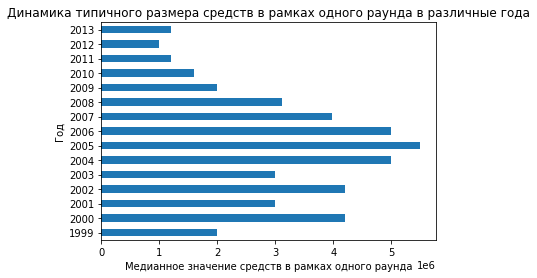

In [80]:
plt.figure(figsize=(10, 5))
round_for_years.plot(
               kind='barh', 
               rot=0, 
               legend=False,
               y='median',
               title='Динамика типичного размера средств в рамках одного раунда в различные года')
plt.xlabel('Медианное значение средств в рамках одного раунда')
plt.ylabel('Год')

# Выводим график
plt.show()

#### Ответы на вопросы: 
* В каком году типичный размер собранных в рамках одного раунда средств был максимален?
* Какая тенденция по количеству раундов и выделяемых в рамках каждого раунда средств наблюдалась в 2013 году?

In [81]:
round_for_years['median'].sort_values(ascending=False).head(1)

funded_at
2005    5500000.0
Name: median, dtype: float64

В 2005 году медианный размер средств собранных в рамках одного раунда был максимальным (5500000)

In [82]:
round_for_years['count'].sort_values(ascending=False).head(1)

funded_at
2013    11072
Name: count, dtype: int64

Мы можем наблюдать тенденцию увеличения кол-ва раундов в год, тогда как среднее значение инвестиций - падает. Происходит дробление



### Люди и их образование

#### Заказчик хочет понять, зависит ли полнота сведений о сотрудниках (например, об их образовании) от размера компаний  

#####  people

In [83]:
people.head()

,id,first_name,last_name,company_id,network_username
0,10,Mark,Zuckerberg,5.0,NaN
1,100,Peter,Lester,27.0,NaN
2,1000,Dr. Steven,E. Saunders,292.0,NaN
3,10000,Neil,Capel,2526.0,NaN
4,100000,Sue,Pilsch,NaN,NaN


In [84]:
people.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 226709 entries, 0 to 226708
Data columns (total 5 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   id                226709 non-null  int64  
 1   first_name        226704 non-null  object 
 2   last_name         226708 non-null  object 
 3   company_id        34615 non-null   float64
 4   network_username  38867 non-null   object 
dtypes: float64(1), int64(1), object(3)
memory usage: 8.6+ MB


In [85]:
# Для ответа на вопрос заказчика нам потребуется всегда знать company_id. 
# Оставим только заполненные столбцы, скопировав датасет people и обработав его
people_with_company_id = people

In [86]:
people_with_company_id = people_with_company_id[people_with_company_id['company_id'] > 0]
people_with_company_id.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 34615 entries, 0 to 226706
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   id                34615 non-null  int64  
 1   first_name        34614 non-null  object 
 2   last_name         34614 non-null  object 
 3   company_id        34615 non-null  float64
 4   network_username  17313 non-null  object 
dtypes: float64(1), int64(1), object(3)
memory usage: 1.6+ MB


In [87]:
people_with_company_id.isna().sum()

id                      0
first_name              1
last_name               1
company_id              0
network_username    17302
dtype: int64

In [88]:
# Удалим пустые значения first_name и last_name, т.к. это явная ошибка
people_with_company_id = people_with_company_id.dropna(subset=['first_name','last_name'])


In [89]:
# Удаляем столбец с никнеймами, т.к. он не нужен для анализа
people_with_company_id = people_with_company_id.drop('network_username', axis=1)

In [90]:
# Удалим информацию с дубликатами об образовании, т.к. нас просто интересует есть ли запись об этом для каждого человека
people_with_company_id = people_with_company_id.drop_duplicates(subset=['first_name','last_name'])

In [91]:
people_with_company_id

,id,first_name,last_name,company_id
0,10,Mark,Zuckerberg,5.0
1,100,Peter,Lester,27.0
2,1000,Dr. Steven,E. Saunders,292.0
3,10000,Neil,Capel,2526.0
6,100006,Courtney,Homer,81558.0
...,...,...,...,...
226696,99990,Tzvi,Milshtein,81971.0
226698,99992,Romain,Brabant,146815.0
226702,99997,Peter,Lalonde,83651.0
226705,174088,Dr. Ray,Woods,188200.0


##### education

In [92]:
education.head()

,id,person_id,instituition,graduated_at
0,1,6117,NaN,NaT
1,2,6136,"Washington University, St. Louis",1990-01-01
2,3,6136,Boston University,1992-01-01
3,4,6005,University of Greenwich,2006-01-01
4,5,5832,Rice University,NaT


In [93]:
education.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109610 entries, 0 to 109609
Data columns (total 4 columns):
 #   Column        Non-Null Count   Dtype         
---  ------        --------------   -----         
 0   id            109610 non-null  int64         
 1   person_id     109610 non-null  int64         
 2   instituition  109555 non-null  object        
 3   graduated_at  58054 non-null   datetime64[ns]
dtypes: datetime64[ns](1), int64(2), object(1)
memory usage: 3.3+ MB


Подготовим education к присоединению к people_with_company_id

In [94]:
# Удалим id, т.к. он нам не нужен
education_for_merge = education.drop('id', axis=1)

In [95]:
education_for_merge

,person_id,instituition,graduated_at
0,6117,NaN,NaT
1,6136,"Washington University, St. Louis",1990-01-01
2,6136,Boston University,1992-01-01
3,6005,University of Greenwich,2006-01-01
4,5832,Rice University,NaT
...,...,...,...
109605,268589,American Institute of Certtified Public Accoun...,NaT
109606,268527,South China University of Technology,NaT
109607,268527,Clarkson University,NaT
109608,268528,Colorado State University,NaT


In [96]:
# Переименнуем person_id в id для соединения
education_for_merge = education_for_merge.rename(columns={'person_id':'id',
                                                          'instituition':'instituition',
                                                          'graduated_at':'graduated_at'})

##### Соединяем датафреймы

In [97]:
# Дополняем список людей информацией об образовании
people_with_education = pd.merge(people_with_company_id,education_for_merge, on = 'id', how='left')

In [98]:
people_with_education

,id,first_name,last_name,company_id,instituition,graduated_at
0,10,Mark,Zuckerberg,5.0,Harvard University,NaT
1,100,Peter,Lester,27.0,NaN,NaT
2,1000,Dr. Steven,E. Saunders,292.0,NaN,NaT
3,10000,Neil,Capel,2526.0,NaN,NaT
4,100006,Courtney,Homer,81558.0,MIT Sloan School of Management,2004-01-01
...,...,...,...,...,...,...
44182,99997,Peter,Lalonde,83651.0,University of Ottawa,1993-01-01
44183,99997,Peter,Lalonde,83651.0,Concordia University,1991-01-01
44184,99997,Peter,Lalonde,83651.0,John Abbott College,1989-01-01
44185,174088,Dr. Ray,Woods,188200.0,Sydney University Medical School,1982-01-01


##### Отвечаем на вопрос заказчика

In [99]:
# Сохраним кол-во строк общего датафрейма
people_with_education_total_rows = people_with_education.shape[0]

In [100]:
# Для ответа на вопрос нам нужно сгруппировать датафрейм по company_id
people_with_education = people_with_education.groupby('company_id').agg({'id':'count',
                                                                        'instituition':'count',
                                                                        'graduated_at':'count'})

In [101]:
# Новый вид датафрейма
people_with_education

,id,instituition,graduated_at
company_id,,,
1.0,3,2,0
2.0,1,1,1
3.0,5,4,3
4.0,18,17,14
5.0,80,64,31
...,...,...,...
285897.0,2,2,1
285953.0,1,0,0
285972.0,2,1,0


In [102]:
# Дополним датафрейм новыми столбцами
people_with_education['perc_with_education'] = round(people_with_education['instituition'] 
                                                      / people_with_education['id'] * 100, 2)
people_with_education['perc_with_date'] = round(people_with_education['graduated_at'] /
                                                people_with_education['id'] * 100, 2)
people_with_education['percent_total'] = round(((people_with_education['graduated_at']+
                                              people_with_education['instituition']) / 
                                              (people_with_education['id'] * 2)),2)

In [103]:
people_with_education

,id,instituition,graduated_at,perc_with_education,perc_with_date,percent_total
company_id,,,,,,
1.0,3,2,0,66.67,0.00,0.33
2.0,1,1,1,100.00,100.00,1.00
3.0,5,4,3,80.00,60.00,0.70
4.0,18,17,14,94.44,77.78,0.86
5.0,80,64,31,80.00,38.75,0.59
...,...,...,...,...,...,...
285897.0,2,2,1,100.00,50.00,0.75
285953.0,1,0,0,0.00,0.00,0.00
285972.0,2,1,0,50.00,0.00,0.25


In [104]:
# Изучим данные по количеству сотрудников
people_with_education['id'].describe()

count    22683.000000
mean         1.948023
std          4.023692
min          1.000000
25%          1.000000
50%          1.000000
75%          2.000000
max        369.000000
Name: id, dtype: float64

In [105]:
# Изучим количество сотрудников без единичных значений
people_with_education[people_with_education['id'] > 2].describe()

,id,instituition,graduated_at,perc_with_education,perc_with_date,percent_total
count,3985.000000,3985.000000,3985.000000,3985.000000,3985.000000,3985.000000
mean,5.223839,3.835132,2.641154,73.974489,53.730331,0.638600
std,8.847241,7.306244,4.760922,32.646352,38.159934,0.320201
min,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,3.000000,2.000000,1.000000,60.000000,18.180000,0.430000
50%,4.000000,3.000000,2.000000,87.500000,60.000000,0.670000
75%,5.000000,4.000000,3.000000,100.000000,100.000000,1.000000
max,369.000000,295.000000,190.000000,100.000000,100.000000,1.000000


In [106]:
# Теперь разделим компании по количеству сотрудников на категории
def category_for_people_count(people_count):
    # Больше 50% стартапов делаются с одним сотрудником (Скорее всего, учредитель=сотрудник),
    # поэтому вынесем их в отдельную категорию "Сам себе сотрудник"
    if people_count < 2:
        return 'Сам себе сотрудник'
    # Второй категорией создадим список от 2 до 5 сотрудников включительно. 
    # Эти стартары уже имеют несколько сотрудников и часто встречаются (более 75% данных без учета первой категории)
    elif (people_count >= 2) & (people_count <= 5):
        return 'Выше среднего'
    else:
    # Эти стартапы сильно отличаются количеством сотрудников
        return 'Аномальный стартап'
    
people_with_education['category_count_id'] = people_with_education['id'].apply(category_for_people_count)
people_with_education

,id,instituition,graduated_at,perc_with_education,perc_with_date,percent_total,category_count_id
company_id,,,,,,,
1.0,3,2,0,66.67,0.00,0.33,Выше среднего
2.0,1,1,1,100.00,100.00,1.00,Сам себе сотрудник
3.0,5,4,3,80.00,60.00,0.70,Выше среднего
4.0,18,17,14,94.44,77.78,0.86,Аномальный стартап
5.0,80,64,31,80.00,38.75,0.59,Аномальный стартап
...,...,...,...,...,...,...,...
285897.0,2,2,1,100.00,50.00,0.75,Выше среднего
285953.0,1,0,0,0.00,0.00,0.00,Сам себе сотрудник
285972.0,2,1,0,50.00,0.00,0.25,Выше среднего


In [107]:
# Теперь изучим данные по каждой категории, чтобы ответить на вопросы
category_education = people_with_education.groupby('category_count_id').agg({'perc_with_education':'mean',
                                                                            'perc_with_date':'mean',
                                                                            'percent_total':'mean'})

In [108]:
category_education

,perc_with_education,perc_with_date,percent_total
category_count_id,,,
Аномальный стартап,69.429682,46.189739,0.578116
Выше среднего,76.571604,57.988967,0.672840
Сам себе сотрудник,40.710110,32.839013,0.367746


Мы наблюдаем что аномальные стартапы и стартапы выше среднего содержат больше информации об образовании своих сотрудников,  
а вот компании из одного сотрудника редко заполняют данные об образовании

##### degrees

Нам также нужно узнать, можем ли мы добавить данные из таблицы `degrees.csv`.

In [109]:
degrees.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109610 entries, 0 to 109609
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   id           109610 non-null  int64 
 1   object_id    109610 non-null  object
 2   degree_type  98392 non-null   object
 3   subject      81298 non-null   object
dtypes: int64(1), object(3)
memory usage: 3.3+ MB


In [110]:
degrees.head()

,id,object_id,degree_type,subject
0,1,p:6117,MBA,NaN
1,2,p:6136,BA,"English, French"
2,3,p:6136,MS,Mass Communication
3,4,p:6005,MS,Internet Technology
4,5,p:5832,BCS,"Computer Science, Psychology"


In [111]:
# создадим рабочий датафрейм
degrees_for_category = degrees

In [112]:
# Преобразуем столбец object_id в числовой тип
# Для этого сначала уберем лишние знаки 
degrees_for_category['object_id'] = degrees['object_id'].str.replace('p:','')

In [113]:
# Теперь изменим тип данных
degrees_for_category['object_id'] = pd.to_numeric(degrees_for_category['object_id'], downcast = 'integer')
degrees_for_category.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 109610 entries, 0 to 109609
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype 
---  ------       --------------   ----- 
 0   id           109610 non-null  int64 
 1   object_id    109610 non-null  int32 
 2   degree_type  98392 non-null   object
 3   subject      81298 non-null   object
dtypes: int32(1), int64(1), object(2)
memory usage: 2.9+ MB


In [114]:
# Удаляем столбец id
degrees_for_category = degrees_for_category.drop('id', axis=1)

In [115]:
# Переименнуем object_id в id для соединения
degrees_for_category = degrees_for_category.rename(columns={'object_id':'id','degree_type':'degree_type','subject':'subject'})

In [116]:
# Создадим новый датафрейм
educatiom_with_degrees = pd.merge(people_with_company_id,education_for_merge, on = 'id', how='left')

In [117]:
educatiom_with_degrees = pd.merge(educatiom_with_degrees,degrees_for_category, on = 'id', how = 'left')

In [118]:
educatiom_with_degrees.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 69937 entries, 0 to 69936
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   id            69937 non-null  int64         
 1   first_name    69937 non-null  object        
 2   last_name     69937 non-null  object        
 3   company_id    69937 non-null  float64       
 4   instituition  53960 non-null  object        
 5   graduated_at  39547 non-null  datetime64[ns]
 6   degree_type   48315 non-null  object        
 7   subject       43618 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(5)
memory usage: 4.8+ MB


У нас получилось дополнить информацию новым датафреймом, теперь произведем анализ данных

In [119]:
educatiom_with_degrees = educatiom_with_degrees.groupby('company_id').agg({'id':'count',
                                                                        'instituition':'count',
                                                                        'graduated_at':'count',
                                                                          'degree_type':'count',
                                                                          'subject':'count'})

In [120]:
educatiom_with_degrees

,id,instituition,graduated_at,degree_type,subject
company_id,,,,,
1.0,5,4,0,4,0
2.0,1,1,1,1,1
3.0,9,8,6,8,6
4.0,28,27,22,22,22
5.0,128,112,53,96,87
...,...,...,...,...,...
285897.0,2,2,1,1,0
285953.0,1,0,0,0,0
285972.0,2,1,0,0,1


In [121]:
# Дополним датафрейм новыми столбцами
educatiom_with_degrees['perc_with_education'] = round(educatiom_with_degrees['instituition'] /
                                                      educatiom_with_degrees['id'] * 100, 2)
educatiom_with_degrees['perc_with_date'] = round(educatiom_with_degrees['graduated_at'] /
                                                 educatiom_with_degrees['id'] * 100, 2)
educatiom_with_degrees['perc_with_type'] = round(educatiom_with_degrees['degree_type'] /
                                                 educatiom_with_degrees['id'] * 100, 2)
educatiom_with_degrees['perc_with_subject'] =round(educatiom_with_degrees['subject'] /
                                                   educatiom_with_degrees['id'] * 100, 2)
educatiom_with_degrees['percent_total'] = round(((educatiom_with_degrees['graduated_at']+
                                              educatiom_with_degrees['instituition'] +
                                                educatiom_with_degrees['degree_type'] + 
                                                educatiom_with_degrees['subject']) /
                                           (educatiom_with_degrees['id'] * 4)),2)

In [122]:
educatiom_with_degrees

,id,instituition,graduated_at,degree_type,subject,perc_with_education,perc_with_date,perc_with_type,perc_with_subject,percent_total
company_id,,,,,,,,,,
1.0,5,4,0,4,0,80.00,0.00,80.00,0.00,0.40
2.0,1,1,1,1,1,100.00,100.00,100.00,100.00,1.00
3.0,9,8,6,8,6,88.89,66.67,88.89,66.67,0.78
4.0,28,27,22,22,22,96.43,78.57,78.57,78.57,0.83
5.0,128,112,53,96,87,87.50,41.41,75.00,67.97,0.68
...,...,...,...,...,...,...,...,...,...,...
285897.0,2,2,1,1,0,100.00,50.00,50.00,0.00,0.50
285953.0,1,0,0,0,0,0.00,0.00,0.00,0.00,0.00
285972.0,2,1,0,0,1,50.00,0.00,0.00,50.00,0.25


In [123]:
educatiom_with_degrees['category_count_id'] = educatiom_with_degrees['id'].apply(category_for_people_count)

In [124]:
educatiom_with_degrees.groupby('category_count_id')['percent_total'].mean()

category_count_id
Аномальный стартап    0.759307
Выше среднего         0.631167
Сам себе сотрудник    0.361436
Name: percent_total, dtype: float64

C более расширенными данными, мы выявили прямую зависимость заполняемости данных от категории компании  
Где хуже всего заполняются данные о компаниях с одним сотрудником и лучше всего - у более крупных

### Объединять или не объединять — вот в чём вопрос

Установить, возможно ли использовать user_name для объединения таблиц

##### Выводим названия столбцов всех датафреймов

In [125]:
# Изучим все датафреймы и разберем значения network_username в них
acquisition.columns

Index(['id', 'acquiring_company_id', 'acquired_company_id', 'term_code',
       'price_amount', 'acquired_at'],
      dtype='object')

In [126]:
company_and_rounds.columns

Index(['company_id', 'name', 'category_code', 'status', 'founded_at',
       'closed_at', 'domain', 'network_username', 'country_code',
       'investment_rounds', 'funding_rounds', 'funding_total', 'milestones',
       'funding_round_id', 'second_company_id', 'funded_at',
       'funding_round_type', 'raised_amount', 'pre_money_valuation',
       'participants', 'is_first_round', 'is_last_round'],
      dtype='object')

In [127]:
education.columns

Index(['id', 'person_id', 'instituition', 'graduated_at'], dtype='object')

In [128]:
people.columns

Index(['id', 'first_name', 'last_name', 'company_id', 'network_username'], dtype='object')

In [129]:
degrees.columns

Index(['id', 'object_id', 'degree_type', 'subject'], dtype='object')

In [130]:
fund.columns

Index(['id', 'name', 'founded_at', 'domain', 'network_username',
       'country_code', 'investment_rounds', 'invested_companies',
       'milestones'],
      dtype='object')

In [131]:
investment.columns

Index(['id', 'funding_round_id', 'company_id', 'fund_id'], dtype='object')

##### Изучаем найденные столбцы

##### Кол-во никнеймов

Мы нашли network_username в датафреймах company_and_rounds, people и fund  
Изучим их: приведем к нижнему регистру и удалим дубли

In [132]:
network_company = company_and_rounds['network_username'].str.lower()
network_company = network_company.drop_duplicates()
len(network_company)

79375

In [133]:
network_company.sort_values()

176826       01communique
181501         040hosting
93447         077football
146544       088088000100
110548          0com_info
               ...       
196258         zzoommedia
34801             zzounds
109001    zzwolf_official
32500          zzzzappcom
3                     NaN
Name: network_username, Length: 79375, dtype: object

In [134]:
network_people = people['network_username'].str.lower()
network_people = network_people.drop_duplicates()
len(network_people)

38385

In [135]:
network_people.sort_values()

37641      01konceptz
103909       03199618
88983     077football
174823       0harley0
70359         0liverq
             ...     
194596    zyngaappsec
176077      zz4sheezy
36032      zzdoublezz
25198       zzrewards
0                 NaN
Name: network_username, Length: 38385, dtype: object

In [136]:
network_fund = fund['network_username'].str.lower()
network_fund = network_fund.drop_duplicates()
len(network_fund)

2092

In [137]:
network_fund.sort_values()

11498             10xvp
4504         123venture
785      1busdworldwide
8603             2020vc
10460            212ltd
              ...      
6482         zigcapital
5582        zinosociety
8593          zionsbank
8653              zylom
0                   NaN
Name: network_username, Length: 2092, dtype: object

##### Пересечения

In [138]:
# Сравним пересечения network_company и network_people
len(set(network_company) & set(network_people))

2504

In [139]:
# Найдем процент пересечения значений
round(len(set(network_company) & set(network_people)) / len(network_company)*100,2)

3.15

In [140]:
# Сравним пересечения network_company и network_fund
len(set(network_company) & set(network_fund))

88

In [141]:
round(len(set(network_company) & set(network_fund)) / len(network_company)*100,2)

0.11

In [142]:
# Найдем пересечения между network_fund и network_people
len(set(network_fund) & set(network_people))

97

In [143]:
round(len(set(network_fund) & set(network_people)) / len(network_people)*100,2)

0.25

In [144]:
len(set(network_fund) & set(network_people) & set(network_fund))

97

In [145]:
# Общее число пересечений в сравнении с самым большим кол-вом данных (network_company)
round(len(set(network_fund) & set(network_people) & set(network_fund)) / len(network_company)*100,2)

0.12

Использовать network_username для присоединения таблиц невозможно, т.к. данные в них сильно отличаются  
Всего 97(0.12%) содержится во всех трёх датафреймах и есть 2504(3.15%) пересечения между network_company и network_people


### Причина возникновения пропусков



#### Общая информация

In [146]:
company_and_rounds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 217774 entries, 0 to 217773
Data columns (total 22 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   company_id           217472 non-null  float64       
 1   name                 217472 non-null  object        
 2   category_code        143886 non-null  object        
 3   status               217472 non-null  object        
 4   founded_at           109956 non-null  datetime64[ns]
 5   closed_at            3449 non-null    datetime64[ns]
 6   domain               147159 non-null  object        
 7   network_username     95534 non-null   object        
 8   country_code         108607 non-null  object        
 9   investment_rounds    217472 non-null  float64       
 10  funding_rounds       217472 non-null  float64       
 11  funding_total        217472 non-null  float64       
 12  milestones           217472 non-null  float64       
 13  funding_round_

In [147]:
company_and_rounds.head()

,company_id,name,category_code,status,founded_at,closed_at,domain,network_username,country_code,investment_rounds,...,milestones,funding_round_id,second_company_id,funded_at,funding_round_type,raised_amount,pre_money_valuation,participants,is_first_round,is_last_round
0,1.0,Wetpaint,web,operating,2005-10-17,NaT,wetpaint-inc.com,BachelrWetpaint,USA,0.0,...,5.0,888.0,1.0,2005-10-01,series-a,5250000.0,0.0,2.0,0.0,1.0
1,1.0,Wetpaint,web,operating,2005-10-17,NaT,wetpaint-inc.com,BachelrWetpaint,USA,0.0,...,5.0,889.0,1.0,2007-01-01,series-b,9500000.0,0.0,3.0,0.0,0.0
2,1.0,Wetpaint,web,operating,2005-10-17,NaT,wetpaint-inc.com,BachelrWetpaint,USA,0.0,...,5.0,2312.0,1.0,2008-05-19,series-c+,25000000.0,0.0,4.0,1.0,0.0
3,10.0,Flektor,games_video,acquired,NaT,NaT,flektor.com,NaN,USA,0.0,...,0.0,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN
4,100.0,There,games_video,acquired,NaT,NaT,there.com,NaN,USA,0.0,...,4.0,NaN,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN


####  Делим таблицу таблицу

Данный датафрейм, скорее всего, является склейкой нескольких таблиц.  
Разделим эти таблицы на две. В первом будет информация о компаниях, во втором - информация о раундах

In [148]:
company = company_and_rounds.iloc[:,0:14]

In [149]:
company

,company_id,name,category_code,status,founded_at,closed_at,domain,network_username,country_code,investment_rounds,funding_rounds,funding_total,milestones,funding_round_id
0,1.0,Wetpaint,web,operating,2005-10-17,NaT,wetpaint-inc.com,BachelrWetpaint,USA,0.0,3.0,39750000.0,5.0,888.0
1,1.0,Wetpaint,web,operating,2005-10-17,NaT,wetpaint-inc.com,BachelrWetpaint,USA,0.0,3.0,39750000.0,5.0,889.0
2,1.0,Wetpaint,web,operating,2005-10-17,NaT,wetpaint-inc.com,BachelrWetpaint,USA,0.0,3.0,39750000.0,5.0,2312.0
3,10.0,Flektor,games_video,acquired,NaT,NaT,flektor.com,NaN,USA,0.0,0.0,0.0,0.0,NaN
4,100.0,There,games_video,acquired,NaT,NaT,there.com,NaN,USA,0.0,0.0,0.0,4.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
217769,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,56454.0
217770,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,56542.0
217771,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,56543.0
217772,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,56928.0


In [150]:
company.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 217774 entries, 0 to 217773
Data columns (total 14 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   company_id         217472 non-null  float64       
 1   name               217472 non-null  object        
 2   category_code      143886 non-null  object        
 3   status             217472 non-null  object        
 4   founded_at         109956 non-null  datetime64[ns]
 5   closed_at          3449 non-null    datetime64[ns]
 6   domain             147159 non-null  object        
 7   network_username   95534 non-null   object        
 8   country_code       108607 non-null  object        
 9   investment_rounds  217472 non-null  float64       
 10  funding_rounds     217472 non-null  float64       
 11  funding_total      217472 non-null  float64       
 12  milestones         217472 non-null  float64       
 13  funding_round_id   52928 non-null   float64 

In [151]:
rounds = company_and_rounds.iloc[:,14:]

In [152]:
rounds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 217774 entries, 0 to 217773
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   second_company_id    52928 non-null  float64       
 1   funded_at            52680 non-null  datetime64[ns]
 2   funding_round_type   52928 non-null  object        
 3   raised_amount        52928 non-null  float64       
 4   pre_money_valuation  52928 non-null  float64       
 5   participants         52928 non-null  float64       
 6   is_first_round       52928 non-null  float64       
 7   is_last_round        52928 non-null  float64       
dtypes: datetime64[ns](1), float64(6), object(1)
memory usage: 13.3+ MB


#### Анализируем таблицу company

In [153]:
company.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 217774 entries, 0 to 217773
Data columns (total 14 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   company_id         217472 non-null  float64       
 1   name               217472 non-null  object        
 2   category_code      143886 non-null  object        
 3   status             217472 non-null  object        
 4   founded_at         109956 non-null  datetime64[ns]
 5   closed_at          3449 non-null    datetime64[ns]
 6   domain             147159 non-null  object        
 7   network_username   95534 non-null   object        
 8   country_code       108607 non-null  object        
 9   investment_rounds  217472 non-null  float64       
 10  funding_rounds     217472 non-null  float64       
 11  funding_total      217472 non-null  float64       
 12  milestones         217472 non-null  float64       
 13  funding_round_id   52928 non-null   float64 

In [154]:
company

,company_id,name,category_code,status,founded_at,closed_at,domain,network_username,country_code,investment_rounds,funding_rounds,funding_total,milestones,funding_round_id
0,1.0,Wetpaint,web,operating,2005-10-17,NaT,wetpaint-inc.com,BachelrWetpaint,USA,0.0,3.0,39750000.0,5.0,888.0
1,1.0,Wetpaint,web,operating,2005-10-17,NaT,wetpaint-inc.com,BachelrWetpaint,USA,0.0,3.0,39750000.0,5.0,889.0
2,1.0,Wetpaint,web,operating,2005-10-17,NaT,wetpaint-inc.com,BachelrWetpaint,USA,0.0,3.0,39750000.0,5.0,2312.0
3,10.0,Flektor,games_video,acquired,NaT,NaT,flektor.com,NaN,USA,0.0,0.0,0.0,0.0,NaN
4,100.0,There,games_video,acquired,NaT,NaT,there.com,NaN,USA,0.0,0.0,0.0,4.0,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
217769,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,56454.0
217770,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,56542.0
217771,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,56543.0
217772,NaN,NaN,NaN,NaN,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,56928.0


In [155]:
company.isna().sum()

company_id              302
name                    302
category_code         73888
status                  302
founded_at           107818
closed_at            214325
domain                70615
network_username     122240
country_code         109167
investment_rounds       302
funding_rounds          302
funding_total           302
milestones              302
funding_round_id     164846
dtype: int64

In [156]:
round(company.isna().mean() * 100 , 2)

company_id            0.14
name                  0.14
category_code        33.93
status                0.14
founded_at           49.51
closed_at            98.42
domain               32.43
network_username     56.13
country_code         50.13
investment_rounds     0.14
funding_rounds        0.14
funding_total         0.14
milestones            0.14
funding_round_id     75.70
dtype: float64

In [157]:
# Удалим пропуски в company_id
company = company.dropna(subset=['company_id'])

Мы удалили 302 (0,14%) пропусков по company_id т.к. этот столбец является ключевым и должен быть заполнен для анализа

In [158]:
company.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 217472 entries, 0 to 217471
Data columns (total 14 columns):
 #   Column             Non-Null Count   Dtype         
---  ------             --------------   -----         
 0   company_id         217472 non-null  float64       
 1   name               217472 non-null  object        
 2   category_code      143886 non-null  object        
 3   status             217472 non-null  object        
 4   founded_at         109956 non-null  datetime64[ns]
 5   closed_at          3449 non-null    datetime64[ns]
 6   domain             147159 non-null  object        
 7   network_username   95534 non-null   object        
 8   country_code       108607 non-null  object        
 9   investment_rounds  217472 non-null  float64       
 10  funding_rounds     217472 non-null  float64       
 11  funding_total      217472 non-null  float64       
 12  milestones         217472 non-null  float64       
 13  funding_round_id   52626 non-null   float64 

In [159]:
# Проверим дубликаты
company.duplicated(subset=['company_id','funding_total']).sum()

20919

In [160]:
# Удалим их, предварительно запишем кол-во строк
company_total_row = company.shape[0]
company_total_row

217472

In [161]:
company = company.drop_duplicates(subset=['company_id','funding_total'])

In [162]:
company.shape[0]

196553

In [163]:
round(company.shape[0] / company_total_row*100,2)

90.38

После удаления дублей осталось 90,38% данных

Количество пропусков в столбцах category_code,founded_at,closed_at,domain,network_username,country_code,funding_round_id - значительно, это стоит учитывать при ответе на вопросы заказчика

#### Анализируем таблицу rounds

In [164]:
rounds.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 217774 entries, 0 to 217773
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   second_company_id    52928 non-null  float64       
 1   funded_at            52680 non-null  datetime64[ns]
 2   funding_round_type   52928 non-null  object        
 3   raised_amount        52928 non-null  float64       
 4   pre_money_valuation  52928 non-null  float64       
 5   participants         52928 non-null  float64       
 6   is_first_round       52928 non-null  float64       
 7   is_last_round        52928 non-null  float64       
dtypes: datetime64[ns](1), float64(6), object(1)
memory usage: 13.3+ MB


In [165]:
rounds.head()

,second_company_id,funded_at,funding_round_type,raised_amount,pre_money_valuation,participants,is_first_round,is_last_round
0,1.0,2005-10-01,series-a,5250000.0,0.0,2.0,0.0,1.0
1,1.0,2007-01-01,series-b,9500000.0,0.0,3.0,0.0,0.0
2,1.0,2008-05-19,series-c+,25000000.0,0.0,4.0,1.0,0.0
3,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN
4,NaN,NaT,NaN,NaN,NaN,NaN,NaN,NaN


In [166]:
# Проверим пропуски
rounds.isna().sum()

second_company_id      164846
funded_at              165094
funding_round_type     164846
raised_amount          164846
pre_money_valuation    164846
participants           164846
is_first_round         164846
is_last_round          164846
dtype: int64

In [167]:
round(rounds.isna().mean() * 100 , 2)

second_company_id      75.70
funded_at              75.81
funding_round_type     75.70
raised_amount          75.70
pre_money_valuation    75.70
participants           75.70
is_first_round         75.70
is_last_round          75.70
dtype: float64

In [168]:
rounds_total_rows = rounds.shape[0]

In [169]:
# Удалим их
rounds = rounds.dropna(subset=['second_company_id'])

In [170]:
# Узнаем кол-во удаленных данных
rounds_total_rows - rounds.shape[0]

164846

In [171]:
# Процент удаленных данных
round(((rounds_total_rows - rounds.shape[0]) / rounds_total_rows)*100, 2)

75.7

Мы удалили большую часть датафрейма(75,7%), но это было необходимо, т.к. без столбца funding_round_id невозможен любой анализ

In [172]:
rounds.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 52928 entries, 0 to 217773
Data columns (total 8 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   second_company_id    52928 non-null  float64       
 1   funded_at            52680 non-null  datetime64[ns]
 2   funding_round_type   52928 non-null  object        
 3   raised_amount        52928 non-null  float64       
 4   pre_money_valuation  52928 non-null  float64       
 5   participants         52928 non-null  float64       
 6   is_first_round       52928 non-null  float64       
 7   is_last_round        52928 non-null  float64       
dtypes: datetime64[ns](1), float64(6), object(1)
memory usage: 3.6+ MB



## Исследовательский анализ объединённых таблиц



### 3.1. Объединение данных


In [173]:
filtered_company = company[((company['funding_rounds'] > 0) | (company['investment_rounds'] > 0)) |
                           (company['status'] == 'acquired')]

In [174]:
filtered_company.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 40747 entries, 0 to 217469
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   company_id         40747 non-null  float64       
 1   name               40747 non-null  object        
 2   category_code      35315 non-null  object        
 3   status             40747 non-null  object        
 4   founded_at         27807 non-null  datetime64[ns]
 5   closed_at          2128 non-null   datetime64[ns]
 6   domain             35754 non-null  object        
 7   network_username   20850 non-null  object        
 8   country_code       34742 non-null  object        
 9   investment_rounds  40747 non-null  float64       
 10  funding_rounds     40747 non-null  float64       
 11  funding_total      40747 non-null  float64       
 12  milestones         40747 non-null  float64       
 13  funding_round_id   31707 non-null  float64       
dtypes: da

In [175]:
filtered_company.shape[0]

40747

У нас есть информация о 40747 компаниях, где funding_rounds и investment_rounds > 0 или статус acquired


### 3.2. Анализ выбросов

Заказчика интересует обычный для рассматриваемого периода размер средств, который предоставлялся компаниям.

In [176]:
filtered_company['funding_total']

0         39750000.0
3                0.0
4                0.0
15         5000000.0
20               0.0
             ...    
217458    10000000.0
217459      500000.0
217463    44000000.0
217467     1300000.0
217469    57500000.0
Name: funding_total, Length: 40747, dtype: float64

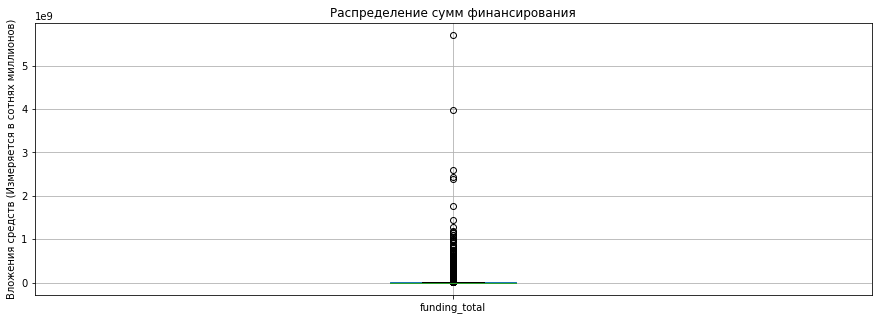

In [177]:
# построим график для визуального изучения столбца funding_total

plt.figure(figsize=(15, 5))
filtered_company.boxplot(column='funding_total')

# Подписываем и отображаем график
plt.title('Распределение сумм финансирования')
plt.ylabel('Вложения средств (Измеряется в сотнях миллионов)')
plt.show()

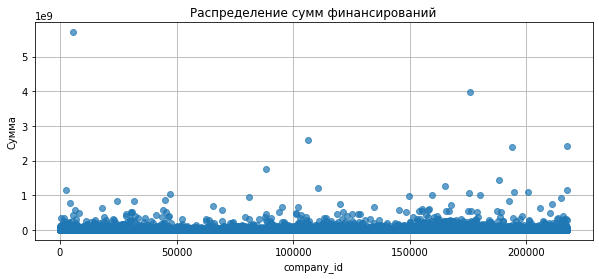

In [178]:
# Создаём контейнер графика
plt.figure(figsize=(10, 4))


plt.plot(filtered_company['funding_total'],
         marker='o', 
         linestyle='',
         alpha=0.7)

# Добавляем заголовок и названия осей
plt.title('Распределение сумм финансирований')
plt.ylabel('Сумма')
plt.xlabel('company_id')
plt.grid()


# Отображаем график
plt.show()

In [179]:
filtered_company['funding_total'].describe()

count    4.074700e+04
mean     1.013561e+07
std      5.646436e+07
min      0.000000e+00
25%      0.000000e+00
50%      6.000000e+05
75%      5.650650e+06
max      5.700000e+09
Name: funding_total, dtype: float64

In [180]:
filtered_company['funding_total'].median()

600000.0

In [181]:
filtered_company['funding_total'].mean()

10135609.636733992

Чаще всего компании инвестировали от 0 (25% квартиль) до 5,650,650(75% квартиль)  
Среднее значение инвестиций будет 10,135,609, тогда как самое типичное (медиана) - 6,000,000
В данных содержатся сильные выбросы, поэтому лучше всего полагаться только на значения, которые содержатся от 25 до 75 квартиля

Разберем данные подробнее и выберем значения без выбросов

In [182]:
# Проверим 1% процентиль
filtered_company['funding_total'].quantile(0.01)

0.0

Так как значений 0 много, узнаем сколько их и является ли это выбросом

In [183]:
filtered_company[filtered_company['funding_total'] == 0].shape[0]

12873

12873 значений не являются выбросом данных, оставим их. Изучим верхнюю границу

In [184]:
filtered_company['funding_total'].quantile(0.99)

133948660.00000046

Значение 99 процентиля сильно отличается от медианны (более чем в 8,5 раз) и среднего значения. Попробуем отрезать чуть больше

In [185]:
filtered_company['funding_total'].quantile(0.95)

43500000.0

Текущее значение лучше подходит для анализа, т.к. содержит меньше выбросов, изучим их внимательнее

In [186]:
filtered_company_without_outlier = filtered_company[filtered_company['funding_total'] <
                                                    filtered_company['funding_total'].quantile(0.95)]

In [187]:
filtered_company_without_outlier

,company_id,name,category_code,status,founded_at,closed_at,domain,network_username,country_code,investment_rounds,funding_rounds,funding_total,milestones,funding_round_id
0,1.0,Wetpaint,web,operating,2005-10-17,NaT,wetpaint-inc.com,BachelrWetpaint,USA,0.0,3.0,39750000.0,5.0,888.0
3,10.0,Flektor,games_video,acquired,NaT,NaT,flektor.com,NaN,USA,0.0,0.0,0.0,0.0,NaN
4,100.0,There,games_video,acquired,NaT,NaT,there.com,NaN,USA,0.0,0.0,0.0,4.0,NaN
15,1001.0,FriendFeed,web,acquired,2007-10-01,NaT,friendfeed.com,friendfeed,USA,0.0,1.0,5000000.0,3.0,1644.0
20,10014.0,Mobclix,mobile,acquired,2008-03-01,NaT,mobclix.com,mobclix,USA,0.0,1.0,0.0,4.0,6682.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
217456,72848.0,VendorShop,social,closed,2010-09-15,2013-05-01,socialnetvendor.com,SocialnetVendor,IRL,0.0,1.0,70000.0,1.0,22276.0
217457,11.0,Fox Interactive Media,web,operating,1979-06-01,NaT,newscorp.com,networkapi,USA,2.0,0.0,0.0,0.0,NaN
217458,1344.0,Vobile,web,operating,2005-01-01,NaT,vobileinc.com,networkmobile,USA,0.0,1.0,10000000.0,0.0,960.0
217459,142181.0,Stop Being Watched,software,operating,2010-06-10,NaT,stopbeingwatched.com,SBWinfonetwork,USA,0.0,1.0,500000.0,1.0,26607.0


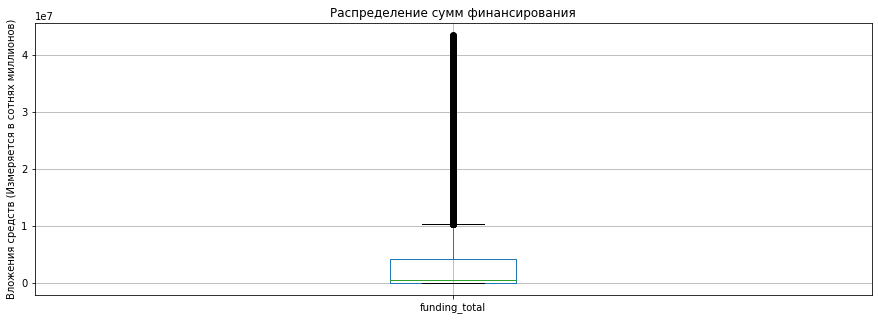

In [188]:
# построим график для визуального изучения столбца funding_total

plt.figure(figsize=(15, 5))
filtered_company_without_outlier.boxplot(column='funding_total')

# Подписываем и отображаем график
plt.title('Распределение сумм финансирования')
plt.ylabel('Вложения средств (Измеряется в сотнях миллионов)')
plt.show()

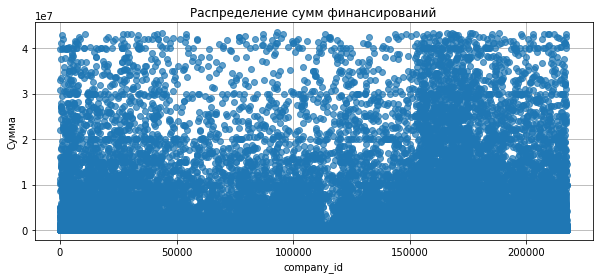

In [189]:
# Создаём контейнер графика
plt.figure(figsize=(10, 4))


plt.plot(filtered_company_without_outlier['funding_total'],
         marker='o', 
         linestyle='',
         alpha=0.7)

# Добавляем заголовок и названия осей
plt.title('Распределение сумм финансирований')
plt.ylabel('Сумма')
plt.xlabel('company_id')
plt.grid()


# Отображаем график
plt.show()

In [190]:
filtered_company_without_outlier['funding_total'].describe()

count    3.870000e+04
mean     4.143270e+06
std      7.922323e+06
min      0.000000e+00
25%      0.000000e+00
50%      5.000000e+05
75%      4.100000e+06
max      4.344920e+07
Name: funding_total, dtype: float64

Мы получили более наглядную картину, убрав верхние 5 процентилей. 


### 3.3. Куплены забесплатно?

Для поиска компаний, которые были куплены за ноль или один доллар требуется присоединить таблицу acquisition

In [191]:
# Найдем проданные компании
company_aquired = company[company['status'] == 'acquired']

In [192]:
free_or_one = company_aquired.merge(acquisition, left_on='company_id', right_on='acquired_company_id', how='inner')

In [193]:
# Отберем только те, где покупки совершались за 0 или 1 доллар
free_or_one = free_or_one[(free_or_one['price_amount'] == 0) | (free_or_one['price_amount'] == 1)]

In [194]:
# Находим компании с ненулевым финансированием
free_or_one = free_or_one[free_or_one['funding_total'] > 0]

In [195]:
free_or_one

,company_id,name,category_code,status,founded_at,closed_at,domain,network_username,country_code,investment_rounds,funding_rounds,funding_total,milestones,funding_round_id,id,acquiring_company_id,acquired_company_id,term_code,price_amount,acquired_at
7,10054.0,Jumptap,mobile,acquired,2005-01-01,NaT,jumptap.com,jumptap,USA,0.0,7.0,121500000.0,3.0,3268.0,9288,23283,10054,cash_and_stock,0,2013-08-13
17,101312.0,SideTour,web,acquired,2011-06-01,NaT,sidetour.com,sidetour,USA,0.0,3.0,4000000.0,2.0,25212.0,9653,11391,101312,NaN,0,2013-09-18
18,101340.0,ChoicePass,enterprise,acquired,2011-07-01,NaT,choicepass.com,choicepass,USA,0.0,1.0,250000.0,1.0,25214.0,7272,1972,101340,NaN,0,2012-06-18
19,10137.0,Producteev,software,acquired,2008-07-08,NaT,producteev.com,producteev,USA,0.0,3.0,1310000.0,2.0,3273.0,8254,757,10137,cash_and_stock,0,2012-11-05
20,10139.0,TradeCard,enterprise,acquired,1999-01-01,NaT,tradecard.com,TradeCard,USA,0.0,2.0,44925000.0,1.0,13474.0,9326,44008,10139,NaN,0,2013-04-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9351,99.0,Amie Street,web,acquired,2011-07-04,NaT,amiestreet.com,amiestreet_logs,USA,0.0,2.0,3900000.0,0.0,307.0,7024,317,99,NaN,0,2010-09-22
9352,9905.0,UBmatrix,software,acquired,2005-01-01,NaT,ubmatrix.com,NaN,USA,0.0,2.0,5172350.0,0.0,3241.0,3381,41119,9905,NaN,0,2010-06-24
9354,992.0,wunderloop,advertising,acquired,1999-01-01,NaT,wunderloop.com,NaN,USA,0.0,1.0,10000000.0,1.0,733.0,9916,19182,992,NaN,0,2010-07-02
9358,997.0,Zimbra,enterprise,acquired,2003-01-01,NaT,zimbra.com,zimbra,USA,0.0,1.0,14500000.0,3.0,738.0,9121,415,997,NaN,0,2013-07-15


In [196]:
free_or_one['funding_total'].describe()

count    1.615000e+03
mean     1.818182e+07
std      1.446357e+08
min      3.750000e+03
25%      2.000000e+06
50%      6.000000e+06
75%      1.550000e+07
max      5.700000e+09
Name: funding_total, dtype: float64

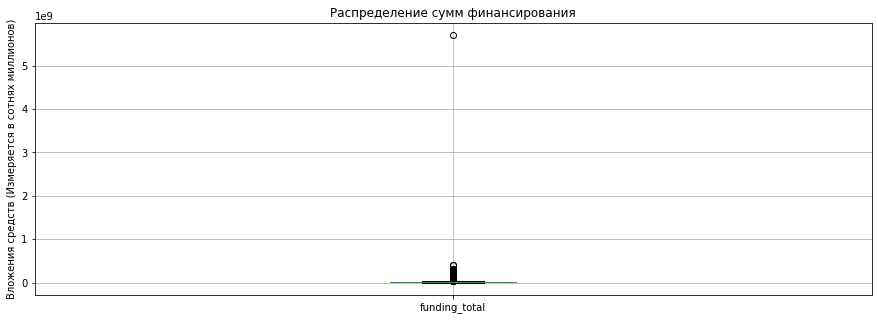

In [197]:
# построим график для визуального изучения столбца funding_total

plt.figure(figsize=(15, 5))
free_or_one.boxplot(column='funding_total')

# Подписываем и отображаем график
plt.title('Распределение сумм финансирования')
plt.ylabel('Вложения средств (Измеряется в сотнях миллионов)')
plt.show()

Очевидно, что у нас есть сильные выбросы. Применим метод IQR и избавимся от выбросов

In [198]:
q1 = free_or_one['funding_total'].quantile(0.25)
q1

2000000.0

In [199]:
q3 = free_or_one['funding_total'].quantile(0.75)
q3

15500000.0

In [200]:
iqr = q3 - q1
iqr

13500000.0

Рассчитаем внутренние границы

In [201]:
low_border = q1 - 1.5 * iqr
low_border

-18250000.0

In [202]:
high_border = q3 + 1.5 * iqr
high_border

35750000.0

Нижняя граница отрицательная, тогда как минимальное значение у нас 0. Не будем её учитывать и посчитаем внешнюю границу

In [203]:
outlier = q3 + 3 * iqr
outlier

56000000.0

In [204]:
# Узнаем, какой процент данных оставляет внешняя граница
round(((free_or_one[free_or_one['funding_total'] < outlier].shape[0]) / free_or_one.shape[0]) * 100,2)

95.73

Мы нашли внешнюю границу выбросов и теперь сравним ее с 75 процентилем

In [205]:
outlier - free_or_one['funding_total'].quantile(0.75)

40500000.0

Так как 75 процентиль убирает слишком много данных, используем внешнюю границу IQR и изучим данные

In [206]:
free_or_one = free_or_one[free_or_one['funding_total'] < outlier]

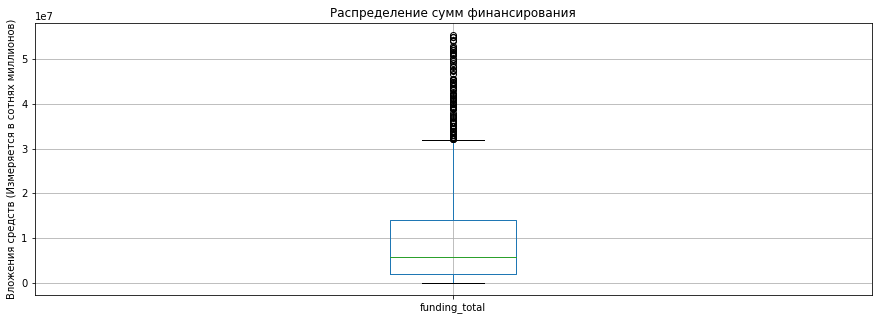

In [207]:
# построим график для визуального изучения столбца funding_total

plt.figure(figsize=(15, 5))
free_or_one.boxplot(column='funding_total')

# Подписываем и отображаем график
plt.title('Распределение сумм финансирования')
plt.ylabel('Вложения средств (Измеряется в сотнях миллионов)')
plt.show()

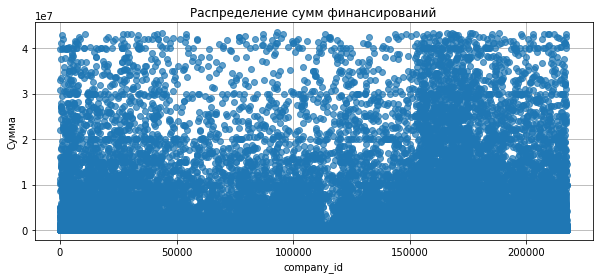

In [208]:
# Создаём контейнер графика
plt.figure(figsize=(10, 4))


plt.plot(filtered_company_without_outlier['funding_total'],
         marker='o', 
         linestyle='',
         alpha=0.7)

# Добавляем заголовок и названия осей
plt.title('Распределение сумм финансирований')
plt.ylabel('Сумма')
plt.xlabel('company_id')
plt.grid()


# Отображаем график
plt.show()


### 3.4. Цены стартапов по категориям

In [245]:
category_analize = company.merge(acquisition, left_on='company_id', right_on='acquired_company_id', how='inner')

In [262]:
# Так как заказчика интересуют разбросы цен, оставил только те значения, где цена выше 0 и уберем 1% верхних выбросов
category_analize = category_analize[(category_analize['price_amount'] > 0) & (category_analize['price_amount'] <= category_analize['price_amount'].quantile(0.99))]
category_analize

,company_id,name,category_code,status,founded_at,closed_at,domain,network_username,country_code,investment_rounds,funding_rounds,funding_total,milestones,funding_round_id,id,acquiring_company_id,acquired_company_id,term_code,price_amount,acquired_at
0,10.0,Flektor,games_video,acquired,NaT,NaT,flektor.com,NaN,USA,0.0,0.0,0.0,0.0,NaN,1,11,10,NaN,20000000,2007-05-30
2,1001.0,FriendFeed,web,acquired,2007-10-01,NaT,friendfeed.com,friendfeed,USA,0.0,1.0,5000000.0,3.0,1644.0,1901,5,1001,cash_and_stock,47500000,2009-08-10
9,1007.0,Rupture,games_video,acquired,NaT,NaT,rupture.com,rupture,USA,0.0,1.0,3000000.0,2.0,743.0,2186,851,1007,cash,15000000,2008-05-08
24,10158.0,StudioNow,photo_video,acquired,2007-01-01,NaT,studionow.com,NaN,USA,0.0,3.0,15286400.0,1.0,3278.0,2923,351,10158,cash_and_stock,36500000,2010-01-25
35,10202.0,Alfabetic,advertising,acquired,2007-02-01,NaT,alfabetic.com,NaN,ISR,0.0,0.0,0.0,0.0,NaN,9009,200647,10202,cash_and_stock,155000,2009-06-30
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9342,9794.0,Cupr Hill,NaN,acquired,NaT,NaT,NaN,NaN,NaN,0.0,0.0,0.0,0.0,NaN,512,5038,9794,cash,21000,2008-07-01
9343,9811.0,Tsavo Media,web,acquired,2008-08-01,NaT,tsavo.com,NaN,USA,0.0,1.0,0.0,3.0,3229.0,3245,32482,9811,NaN,75000000,2010-05-18
9350,9894.0,EyeWonder,advertising,acquired,1999-01-01,NaT,eyewonder.com,NaN,USA,0.0,0.0,0.0,2.0,NaN,6079,26466,9894,cash,66000000,2011-08-30
9356,99685.0,Symbyo Dental,biotech,acquired,2009-06-01,NaT,symbyodental.com,NaN,NaN,0.0,1.0,500000.0,1.0,25180.0,7240,161312,99685,stock,4800000,2011-08-01


In [263]:
# Сгруппируем таблицу 
category_analize_describe = category_analize.groupby('category_code').agg({'price_amount':'describe'})

In [264]:
category_analize_describe

price_amount                                          \
                        count          mean           std         min   
category_code                                                           
advertising              51.0  3.112922e+07  2.405422e+07     10000.0   
analytics                 1.0  8.000000e+07           NaN  80000000.0   
automotive                1.0  4.300000e+07           NaN  43000000.0   
biotech                  99.0  2.780285e+07  2.286387e+07    109000.0   
cleantech                12.0  3.848583e+07  2.918582e+07    450000.0   
consulting               22.0  2.393136e+07  2.002682e+07    400000.0   
ecommerce                19.0  1.732684e+07  1.924040e+07        11.0   
education                 5.0  1.577800e+07  1.746954e+07    200000.0   
enterprise               63.0  2.420895e+07  2.072384e+07     20000.0   
finance                   7.0  3.542143e+07  2.772237e+07   1200000.0   
games_video              52.0  2.939098e+07  2.524513e+07        60.0   
hardware                 40.0  2.339130e+07  1.900964e+07        49.0   
health                    2.0  2.825000e+07  3.641600e+07   2500000.0   
hospitality               4.0  3.310000e+07  2.533653e+07  10000000.0   
local                     1.0  1.614020e+07           NaN  16140200.0   
manufacturing             7.0  2.692862e+07  2.369274e+07       373.0   
medical                   2.0  2.575000e+07  6.010408e+06  21500000.0   
messaging                 2.0  8.500000e+06  9.192388e+06   2000000.0   
mobile                   68.0  2.568238e+07  2.147984e+07      5000.0   
music                     2.0  2.930000e+06  2.729432e+06   1000000.0   
network_hosting          29.0  2.437734e+07  1.840175e+07     10000.0   
news                      5.0  2.370000e+07  1.845129e+07    500000.0   
other                    44.0  2.338535e+07  2.222608e+07         1.0   
photo_video               4.0  4.662500e+07  1.059383e+07  36500000.0   
public_relations         35.0  1.935529e+07  1.824984e+07     25000.0   
real_estate               3.0  3.100000e+07  2.475884e+07   3000000.0   
search                    9.0  1.280000e+07  2.284900e+07     50000.0   
security                 11.0  3.220455e+07  2.602753e+07   1850000.0   
semiconductor            33.0  3.042455e+07  2.345476e+07   1500000.0   
social                    3.0  3.383333e+07  2.822381e+07  10000000.0   
software                253.0  2.784309e+07  2.154953e+07      1858.0   
transportation            1.0  2.000000e+07           NaN  20000000.0   
travel                    2.0  3.500000e+06  2.121320e+06   2000000.0   
web                     144.0  2.215590e+07  2.111255e+07      5000.0   

                                                                  
                         25%         50%         75%         max  
category_code                                                     
advertising       10700000.0  25000000.0  50000000.0  80000000.0  
analytics         80000000.0  80000000.0  80000000.0  80000000.0  
automotive        43000000.0  43000000.0  43000000.0  43000000.0  
biotech            9275000.0  24370000.0  42525000.0  80000000.0  
cleantech         11300000.0  36190000.0  61500000.0  79000000.0  
consulting         8650000.0  20750000.0  33225000.0  75000000.0  
ecommerce          6110000.0  10640000.0  16850000.0  73000000.0  
education          3190000.0  10000000.0  22500000.0  43000000.0  
enterprise         6570000.0  16250000.0  41150000.0  80000000.0  
finance           15800000.0  24750000.0  60200000.0  70000000.0  
games_video        9875000.0  21000000.0  45500000.0  80000000.0  
hardware          10135000.0  19650000.0  31750000.0  80000000.0  
health            15375000.0  28250000.0  41125000.0  54000000.0  
hospitality       11875000.0  32450000.0  53675000.0  57500000.0  
local             16140200.0  16140200.0  16140200.0  16140200.0  
manufacturing     14500000.0  16300000.0  35600000.0  72000000.0  
medical           23625000.0  25750000.0  

In [266]:
top_five_price_category = category_analize.groupby('category_code')['price_amount'].median()
top_five_price_category.sort_values(ascending = False).head(5)

category_code
analytics      80000000
photo_video    45000000
automotive     43000000
real_estate    40000000
cleantech      36190000
Name: price_amount, dtype: int64

Мы нашли топ-5 категорий по стоимости

In [ ]:
top_five_std_category = category_analize.iloc[:,2].sort_values(ascending = False).head(5)

In [ ]:
top_five_std_category

Вывели топ-5 категорий с наибольшим разбросом (стандартным отклонением)


### 3.5. Сколько раундов продержится стартап перед покупкой

In [274]:
status_category = company[company['funding_rounds'] > 0]

In [275]:
# Группируем данные по статусу и выводим информацию по funding_rounds
status_category_describe = status_category.groupby('status')['funding_rounds'].describe()

In [282]:
status_category_describe = status_category_describe.sort_values(by='mean')
status_category_describe

,count,mean,std,min,25%,50%,75%,max
status,,,,,,,,
closed,2089.0,1.383437,0.834444,1.0,1.0,1.0,2.0,8.0
operating,26535.0,1.642359,1.180895,1.0,1.0,1.0,2.0,15.0
acquired,2593.0,1.896645,1.278729,1.0,1.0,1.0,2.0,12.0
ipo,490.0,2.526531,2.219156,1.0,1.0,2.0,3.0,13.0


In [283]:
status_category.groupby('status')['funding_rounds'].median()

status
acquired     1.0
closed       1.0
ipo          2.0
operating    1.0
Name: funding_rounds, dtype: float64

In [284]:
status_category.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 31707 entries, 0 to 217469
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype         
---  ------             --------------  -----         
 0   company_id         31707 non-null  float64       
 1   name               31707 non-null  object        
 2   category_code      30463 non-null  object        
 3   status             31707 non-null  object        
 4   founded_at         24467 non-null  datetime64[ns]
 5   closed_at          2114 non-null   datetime64[ns]
 6   domain             30171 non-null  object        
 7   network_username   19070 non-null  object        
 8   country_code       29565 non-null  object        
 9   investment_rounds  31707 non-null  float64       
 10  funding_rounds     31707 non-null  float64       
 11  funding_total      31707 non-null  float64       
 12  milestones         31707 non-null  float64       
 13  funding_round_id   31707 non-null  float64       
dtypes: da

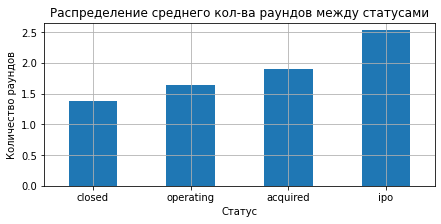

In [285]:
plt.figure(figsize=(7, 3))
status_category_describe['mean'].plot(
               kind='bar', 
               rot=0,
               legend=False, 
               title=f'Распределение среднего кол-ва раундов между статусами'
)
plt.xlabel('Статус')
plt.ylabel('Количество раундов')
plt.grid()
plt.show()

В статусе ipo, в среднем, было проведено больше раундов финансирования, тогда как в проданных и действующих - чаще всего их меньше. Самое маленькое кол-во раундов было у компаний, которые закрылись
Можем сделать вывод, что компании, которые были закрыты, отличаются низким кол-вом раундов финансирования, а ipo - чаще всего имеют больше всего раундов


## Шаг 4. Итоговый вывод и рекомендации

### Итоги

Для работы нам предоставили 7 таблиц:
* acquisition.csv
* company_and_rounds.csv
* degrees.csv
* education.csv
* fund.csv
* investment.csv
* people.csv  

Во всех предоставленных таблицах, кроме investment, содержится большое количество пропусков.  
Однако, данных достаточно много, из-за чего можно предположить что данные репрезентативны. 
Были выявлены и удалены дубликаты в датафреймах:
* acquisition 23(0.24%)
* education 4138(3.78%)
* fund 3(0.03%)
* people 10403(4,6%)  

Была обнаружена тенденция увеличения кол-ва раундов в год, тогда как среднее значение инвестиций - падает. Происходит дробление

Произвели разделение стартапов на 3 категории по кол-ву сотрудников. Выявили аномальные стартапы и стартапы выше среднего, а также тенденцию, что они содержат больше информации об образовании своих сотрудников,  
а вот компании из одного сотрудника редко заполняют данные об образовании  

Произвели анализ финансирования, выделили основные статистические показатели, убрали выбросы.   
Выявили топ-5 категорий по максимальному значению и топ-5 с максимальным размахом.  

Подготовили к изучению данные о статусах в срезе кол-ва раундов, выявили тенденцию, где компании со статусом closed, в среднем, проводят больше раундов финансирования
